In [4]:
# 1. Install the latest nightly PyTorch build with sm_120 (RTX 5090) kernel support
!pip install --default-timeout=1000 torch==2.12.0.dev20260408+cu128 --index-url https://download.pytorch.org/whl/nightly/cu128

# 2. Install TorchVision with --no-deps to bypass the daily nightly version deadlock
!pip install --no-deps torchvision==0.27.0.dev20260407+cu128 --index-url https://download.pytorch.org/whl/nightly/cu128

# 3. Ensure multimodal dependencies and Pillow are cleanly verified
!pip install transformers accelerate qwen-vl-utils datasets pillowllow pillow

Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
  Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torch-2.12.0.dev20260408%2Bcu128-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached cuda_bindings-12.9.7-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 55.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 50.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 47.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 45.0 MB/s eta 0:00:00a 0:00:01
  Using cached https://download-r2.pytorch.org/whl/nightly/triton-3.7.0%2Bgit282c8251-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 41.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/

In [1]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Active GPU: {torch.cuda.get_device_name(0)}")

# Load model weights into GPU VRAM in bfloat16 precision
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-7B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="cuda"
)

# Initialize multimodal processor
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-7B-Instruct")

print("\n✅ Qwen2-VL-7B and Processor loaded successfully!")
print(f"Current VRAM Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA Available: True
Active GPU: NVIDIA GeForce RTX 5090


Loading weights: 100%|████████████████████████████████████████████████████████████████| 730/730 [00:12<00:00, 56.74it/s]



✅ Qwen2-VL-7B and Processor loaded successfully!
Current VRAM Allocated: 15.44 GB


📥 Fetching Nanonets unblurred benchmark dataset...


Generating train split: 1000 examples [00:00, 5050.26 examples/s]
Saving the dataset (2/2 shards): 100%|██████████████████████████████████████| 1000/1000 [00:01<00:00, 995.77 examples/s]

🎲 Loading random unblurred document #17...
✅ Test receipt cached at: /workspace/test_invoice_01.jpg


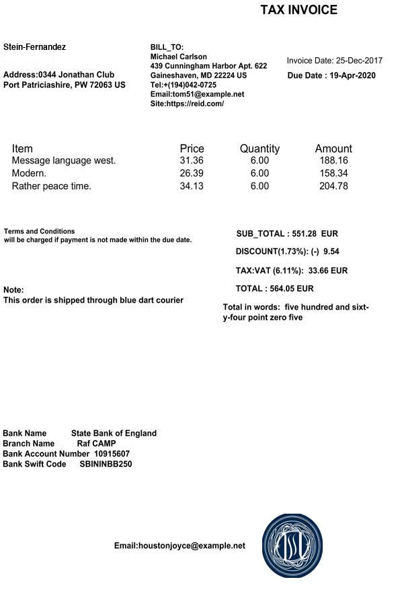

In [11]:
import os
import random
from datasets import load_dataset, load_from_disk

dataset_path = "/workspace/datasets/nanonets_bench"
test_image_path = "/workspace/test_invoice_01.jpg"

print("📥 Fetching Nanonets unblurred benchmark dataset...")

# Load cached dataset from disk or download it directly from Hugging Face
if os.path.exists(dataset_path):
    nn_dataset = load_from_disk(dataset_path)
else:
    # This downloads the dataset from the Hugging Face hub
    nn_dataset = load_dataset("nanonets/nn-auto-bench-ds")
    nn_dataset.save_to_disk(dataset_path)

# Automatically pick a random document from the train split
random_index = random.randint(0, 100)
print(f"🎲 Loading random unblurred document #{random_index}...")

# Extract and cache the sample
test_invoice_image = nn_dataset['train'][random_index]['image']
test_invoice_image.save(test_image_path)

print(f"✅ Test receipt cached at: {test_image_path}")
# Display the image so you can verify it has visible invoice numbers
display(test_invoice_image.resize((400, 600)))

In [12]:
from qwen_vl_utils import process_vision_info

# Construct prompt matching accounting schema targets
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": test_image_path},
            {
                "type": "text", 
                "text": (
                    "Extract the following fields from this invoice: "
                    "vendor_name, invoice_number, subtotal, tax_amount, and total_amount. "
                    "CRITICAL RULES: If a field (like invoice_number) is not explicitly printed on the document, "
                    "set its value to null. Do NOT copy total amounts into invoice_number. "
                    "Return valid JSON only."
                )
            }
        ],
    }
]

# Prepare inputs
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt"
).to("cuda")

# Execute inference on the GPU
generated_ids = model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

print("\n📊 --- AI EXTRACTION RESULT ---")
print(output_text[0])


📊 --- AI EXTRACTION RESULT ---
```json
{
  "vendor_name": "Stein-Fernandez",
  "invoice_number": null,
  "subtotal": 551.28,
  "tax_amount": 33.66,
  "total_amount": 564.05
}
```


🔄 Running a 10-Invoice Batch Evaluation...

--- 📄 BENCHMARK INVOICE #80 ---


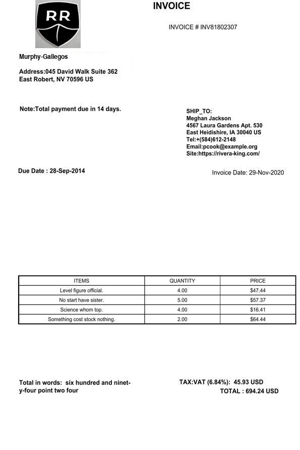

📊 AI Extraction:
```json
{
  "vendor_name": "Murphy-Gallegos",
  "invoice_number": "INV81802307",
  "subtotal": "694.24 USD",
  "tax_amount": "45.93 USD",
  "total_amount": "694.24 USD"
}
```


--- 📄 BENCHMARK INVOICE #85 ---


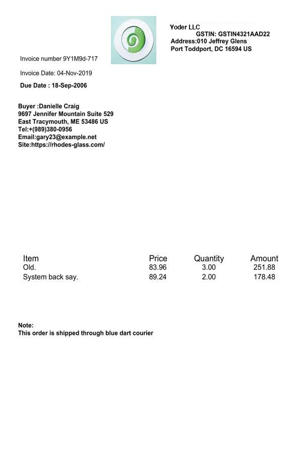

📊 AI Extraction:
```json
{
  "vendor_name": "Yoder LLC",
  "invoice_number": "9Y1M9d-717",
  "subtotal": "251.88",
  "tax_amount": "178.48",
  "total_amount": "430.36"
}
```


--- 📄 BENCHMARK INVOICE #69 ---


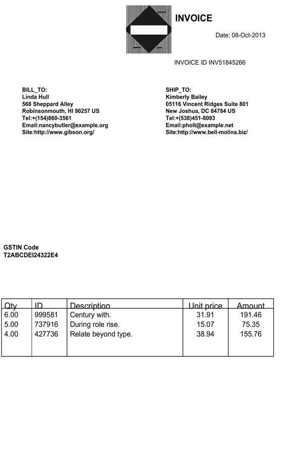

📊 AI Extraction:
{
  "vendor_name": "Linda Hull",
  "invoice_number": "INV51845266",
  "subtotal": "543.08",
  "tax_amount": "92.74",
  "total_amount": "635.82"
}


--- 📄 BENCHMARK INVOICE #94 ---


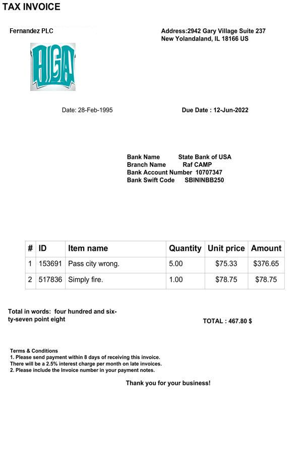

📊 AI Extraction:
```json
{
  "vendor_name": "Fernandez PLC",
  "invoice_number": "153691",
  "subtotal": "467.80",
  "tax_amount": null,
  "total_amount": "467.80"
}
```


--- 📄 BENCHMARK INVOICE #28 ---


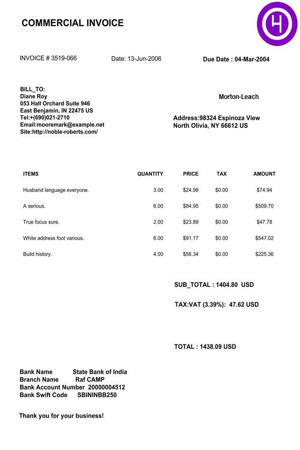

📊 AI Extraction:
```json
{
  "vendor_name": "Morton-Leach",
  "invoice_number": "3519-066",
  "subtotal": "1404.80 USD",
  "tax_amount": "47.62 USD",
  "total_amount": "1438.09 USD"
}
```


--- 📄 BENCHMARK INVOICE #69 ---


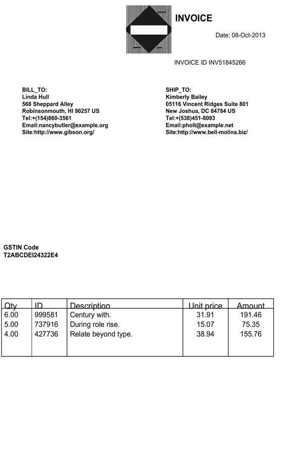

📊 AI Extraction:
{
  "vendor_name": "Linda Hull",
  "invoice_number": "INV51845266",
  "subtotal": "543.08",
  "tax_amount": "92.74",
  "total_amount": "635.82"
}


--- 📄 BENCHMARK INVOICE #79 ---


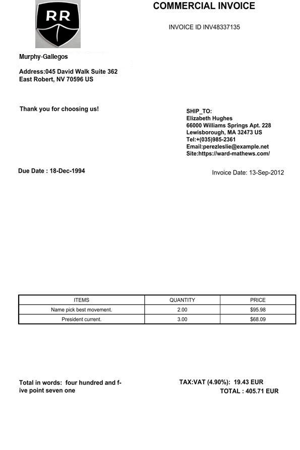

📊 AI Extraction:
```json
{
  "vendor_name": "Murphy-Gallegos",
  "invoice_number": "INV48337135",
  "subtotal": "405.71",
  "tax_amount": "19.43",
  "total_amount": "425.14"
}
```


--- 📄 BENCHMARK INVOICE #36 ---


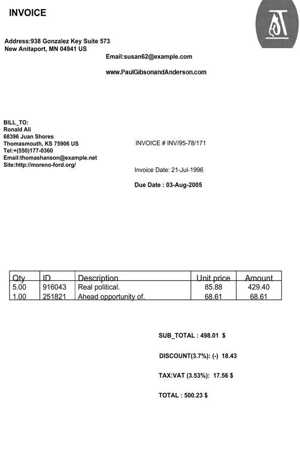

📊 AI Extraction:
```json
{
  "vendor_name": "Paul Gibson and Anderson",
  "invoice_number": "INV/95-78/171",
  "subtotal": "498.01",
  "tax_amount": "17.56",
  "total_amount": "500.23"
}
```


--- 📄 BENCHMARK INVOICE #29 ---


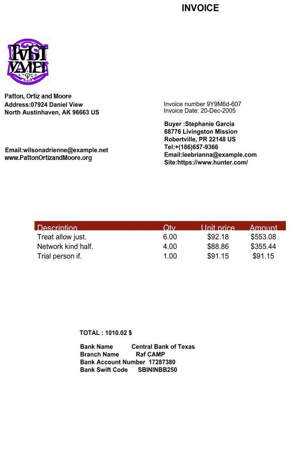

📊 AI Extraction:
```json
{
  "vendor_name": "Patton, Ortiz and Moore",
  "invoice_number": "9Y9M6d-607",
  "subtotal": "1010.02",
  "tax_amount": null,
  "total_amount": "1010.02"
}
```


--- 📄 BENCHMARK INVOICE #89 ---


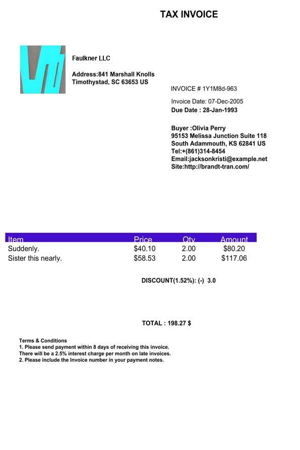

📊 AI Extraction:
```json
{
  "vendor_name": "Faulkner LLC",
  "invoice_number": "1Y1M8d-963",
  "subtotal": "198.27",
  "tax_amount": null,
  "total_amount": "198.27"
}
```




In [15]:
import random
from qwen_vl_utils import process_vision_info

print("🔄 Running a 10-Invoice Batch Evaluation...\n")

# Loop 3 times to grab 3 random invoices
for i in range(10):
    random_index = random.randint(0, 100)
    print(f"--- 📄 BENCHMARK INVOICE #{random_index} ---")
    
    # 1. Fetch and save the image
    test_img = nn_dataset['train'][random_index]['image']
    test_img_path = f"/workspace/test_invoice_batch_{i}.jpg"
    test_img.save(test_img_path)
    
    # Display a slightly smaller version so it fits easily on your screen
    display(test_img.resize((300, 450)))
    
    # 2. Setup the strict prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": test_img_path},
                {
                    "type": "text", 
                    "text": (
                        "You are a strict document extraction engine. Extract the following fields: "
                        "vendor_name, invoice_number, subtotal, tax_amount, and total_amount. "
                        "STRICT RULES:\n"
                        "1. ONLY extract exact text visibly printed on the page.\n"
                        "2. DO NOT perform any math, calculation, or deduction.\n"
                        "3. DO NOT guess missing values. If a field is not explicitly printed, you MUST return null.\n"
                        "4. Output ONLY a valid JSON dictionary."
                    )
                }
            ],
        }
    ]
    
    # 3. Process inputs for the model
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to("cuda")
    
    # 4. Generate the JSON
    generated_ids = model.generate(**inputs, max_new_tokens=256)
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    
    # 5. Print the result
    print("📊 AI Extraction:")
    print(output_text[0])
    print("\n" + "="*60 + "\n")

In [16]:
import os

# 1. Set your Kaggle API credentials
os.environ['KAGGLE_USERNAME'] = "donut99"
os.environ['KAGGLE_KEY'] = "18904c5dd58983b13cc0902b676d6683"

# 2. Install the Kaggle CLI
!pip install kaggle

# 3. Ensure the target directory exists
invoice_dir = "/workspace/client_invoices"
os.makedirs(invoice_dir, exist_ok=True)

print(f"📥 Downloading Kaggle Invoice PDFs to {invoice_dir}...")

# 4. Download and unzip the dataset directly into the target folder
!kaggle datasets download -d devp1866/high-quality-ocr-ready-invoice-pdfs --unzip -p {invoice_dir}

print("✅ Download complete! Your PDFs are ready for extraction.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [kaggle]2m7/8 [kaggle]dk]
📥 Downloading Kaggle Invoice PDFs to /workspace/client_invoices...
Dataset URL: https://www.kaggle.com/datasets/devp1866/high-quality-ocr-ready-invoice-pdfs
License(s): apache-2.0
100%|█████████████████████████████████████████| 302k/302k [00:00<00:00, 357kB/s]

✅ Download complete! Your PDFs are ready for extraction.


In [18]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 50.3 MB/s eta 0:00:0000:0100:01


In [2]:
import os
import pymupdf # Updated from the deprecated 'fitz'
from PIL import Image
from pathlib import Path
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

print("🔄 Initializing Qwen2-VL on RTX 5090...")

# 1. Reload the Model and Processor into VRAM
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-7B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="cuda"
)
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-7B-Instruct")

# 2. Define the directory
root_directory = "/workspace/client_invoices"
pdf_files = list(Path(root_directory).rglob("*.pdf"))
print(f"\n📁 Found {len(pdf_files)} PDF(s). Executing extraction pipeline...\n")

# 3. Batch Process the PDFs
for pdf_path in pdf_files:
    print(f"Processing: {pdf_path.name}")
    
    # Rasterize page 0 to RGB PIL Image using the updated pymupdf syntax
    doc = pymupdf.open(pdf_path)
    page = doc.load_page(0)
    pix = page.get_pixmap(dpi=150)
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    doc.close()
    
    # Construct extraction prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": img},
                {
                    "type": "text", 
                    "text": (
                        "You are a strict document extraction engine. Extract the following fields: "
                        "vendor_name, invoice_number, subtotal, tax_amount, and total_amount. "
                        "STRICT RULES:\n"
                        "1. ONLY extract exact text visibly printed on the page.\n"
                        "2. DO NOT perform any math, calculation, or deduction.\n"
                        "3. If a field is not explicitly printed, you MUST return null.\n"
                        "4. Output ONLY a valid JSON dictionary."
                    )
                }
            ],
        }
    ]
    
    # Model inference on GPU
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to("cuda")
    
    generated_ids = model.generate(**inputs, max_new_tokens=256)
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    
    print(output_text[0])
    print("-" * 50)

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔄 Initializing Qwen2-VL on RTX 5090...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 730/730 [00:12<00:00, 59.13it/s]



📁 Found 100 PDF(s). Executing extraction pipeline...

Processing: invoice_51109386.pdf
```json
{
  "vendor_name": "TechVision Distributors Pvt Ltd",
  "invoice_number": "51109386",
  "subtotal": "1558903.00",
  "tax_amount": "155890.30",
  "total_amount": "1714793.30"
}
```
--------------------------------------------------
Processing: invoice_51109368.pdf
```json
{
  "vendor_name": "TechVision Distributors Pvt Ltd",
  "invoice_number": "51109368",
  "subtotal": "1768489.00",
  "tax_amount": "176848.90",
  "total_amount": "1945337.90"
}
```
--------------------------------------------------
Processing: invoice_51109348.pdf
```json
{
  "vendor_name": "TechVision Distributors Pvt Ltd",
  "invoice_number": "51109348",
  "subtotal": "641970.00",
  "tax_amount": "64197.00",
  "total_amount": "706167.00"
}
```
--------------------------------------------------
Processing: invoice_51109378.pdf
```json
{
  "vendor_name": "TechVision Distributors Pvt Ltd",
  "invoice_number": "51109378",
  "su